<a href="https://colab.research.google.com/github/emraankazmi5-coder/deeplearning/blob/main/CelebA_VAE_Homework_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports and Data Loading & Install Required Packages
!pip install kagglehub -q
!pip install opencv-python-headless -q
print("Packages installed!")
import os
import numpy as np
import cv2
import kagglehub
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input, backend as K
from tensorflow.keras.optimizers import Adam

print("Packages imported successfully!")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Parameters
IMG_SIZE = 64
BATCH_SIZE = 128
LATENT_DIM = 128
EPOCHS = 5
NUM_SAMPLES = 10000

print(f"Parameters: IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}")
print(f"LATENT_DIM={LATENT_DIM}, EPOCHS={EPOCHS}, NUM_SAMPLES={NUM_SAMPLES}")

Packages installed!
Packages imported successfully!
Parameters: IMG_SIZE=64, BATCH_SIZE=128
LATENT_DIM=128, EPOCHS=5, NUM_SAMPLES=10000


In [2]:
# Download and Load CelebA Data
# Using kagglehub (classmate's working approach)
print("Downloading CelebA dataset using kagglehub...")
dataset_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"Dataset downloaded to: {dataset_path}")

# List files to understand structure
print("\nFiles in dataset:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... and {len(files)-3} more files')

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset downloaded to: /kaggle/input/celeba-dataset

Files in dataset:
celeba-dataset/
  list_landmarks_align_celeba.csv
  list_eval_partition.csv
  list_attr_celeba.csv
  ... and 1 more files
  img_align_celeba/
    img_align_celeba/
      083648.jpg
      168202.jpg
      125778.jpg
      ... and 202596 more files


In [3]:
# Load Images with OpenCV
# Find img_align_celeba directory (nested path in kagglehub)
img_dir = None
for root, dirs, files in os.walk(dataset_path):
    if 'img_align_celeba' in root and files and any(f.endswith('.jpg') for f in files):
        img_dir = root
        break

if img_dir is None:
    img_dir = os.path.join(dataset_path, 'img_align_celeba', 'img_align_celeba')

print(f"Image directory: {img_dir}")

# Load attribute labels (list_attr_celeba.csv - CSV format with commas)
attr_file = None
for root, dirs, files in os.walk(dataset_path):
    if 'list_attr_celeba.csv' in files:
        attr_file = os.path.join(root, 'list_attr_celeba.csv')
        break

print(f"Attribute file: {attr_file}")

# Load all image files
image_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith('.jpg')])
print(f"Total images in dataset: {len(image_files)}")

Image directory: /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba
Attribute file: /kaggle/input/celeba-dataset/list_attr_celeba.csv
Total images in dataset: 202599


In [4]:
# Parse Attributes and Filter by Hair Color
# Read attribute labels

# Ensure attr_file is correctly set, even if it came as None from previous cell
if attr_file is None and 'dataset_path' in globals():
    import os
    attr_file = os.path.join(dataset_path, 'list_attr_celeba.csv')
    print(f"Corrected attr_file path: {attr_file}")

with open(attr_file, 'r') as f:
    all_lines = f.readlines()

# The first line contains attribute names. Split by comma and remove 'image_id'.
full_attr_header = all_lines[0].strip().split(',')
attr_names = full_attr_header[1:] # Actual attribute names without 'image_id'

print(f"Attribute names ({len(attr_names)}): {attr_names[:10]}...")

# Find column indices for key attributes relative to attr_names (without 'image_id')
male_idx = attr_names.index('Male')
smile_idx = attr_names.index('Smiling')
glasses_idx = attr_names.index('Eyeglasses') # Corrected from 'Wearing_Eyeglasses'
black_hair_idx = attr_names.index('Black_Hair')
blond_hair_idx = attr_names.index('Blond_Hair')

print(f"Indices: Male={male_idx}, Smiling={smile_idx}, Glasses={glasses_idx}")
print(f"Black_Hair={black_hair_idx}, Blond_Hair={blond_hair_idx}")

# Parse attributes for each image
attr_dict = {}  # filename -> list of attribute values
# Data starts from the second line (index 1)
for line in all_lines[1:]:
    parts = line.strip().split(',')
    filename = parts[0]
    # The attribute values start from the second element in parts (index 1)
    # These directly correspond to attr_names
    attrs = [int(x) for x in parts[1:]]
    attr_dict[filename] = attrs

print(f"Loaded attributes for {len(attr_dict)} images")

Attribute names (40): ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair']...
Indices: Male=20, Smiling=31, Glasses=15
Black_Hair=8, Blond_Hair=9
Loaded attributes for 202599 images


In [5]:
# Filter by Black/Blonde Hair and Load Images
# Filter images: only black hair or blonde hair
filtered_files = []
for f in image_files:
    if f in attr_dict:
        attrs = attr_dict[f]
        if attrs[black_hair_idx] == 1 or attrs[blond_hair_idx] == 1:
            filtered_files.append(f)

print(f"Filtered files (black/blonde hair): {len(filtered_files)}")

# Subsample to NUM_SAMPLES if needed
if len(filtered_files) > NUM_SAMPLES:
    np.random.shuffle(filtered_files)
    filtered_files = filtered_files[:NUM_SAMPLES]

print(f"Using {len(filtered_files)} images for training")

# Load and preprocess images
print("Loading and preprocessing images...")
images = []
for i, f in enumerate(filtered_files):
    img_path = os.path.join(img_dir, f)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype('float32') / 255.0
        images.append(img)
    if (i+1) % 1000 == 0:
        print(f"Loaded {i+1}/{len(filtered_files)} images")

images = np.array(images)
print(f"Loaded {len(images)} images with shape: {images.shape}")
print(f"Pixel range: [{images.min():.3f}, {images.max():.3f}]")

Filtered files (black/blonde hair): 78452
Using 10000 images for training
Loading and preprocessing images...
Loaded 1000/10000 images
Loaded 2000/10000 images
Loaded 3000/10000 images
Loaded 4000/10000 images
Loaded 5000/10000 images
Loaded 6000/10000 images
Loaded 7000/10000 images
Loaded 8000/10000 images
Loaded 9000/10000 images
Loaded 10000/10000 images
Loaded 10000 images with shape: (10000, 64, 64, 3)
Pixel range: [0.000, 1.000]


In [6]:
# VAE Model - Encoder and Decoder
# Following professor's Keras/TensorFlow style (slides 13-20)

# ENCODER
def build_encoder(img_size, latent_dim):
    encoder_input = Input(shape=(img_size, img_size, 3), name='encoder_input')
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(encoder_input)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)  # 32x32
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)  # 16x16
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)  # 8x8
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)  # 4x4
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)

    # VAE: mu and log_var
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

    # Sampling layer
    class Sampling(layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = Sampling()([z_mean, z_log_var])

    encoder = Model(encoder_input, [z_mean, z_log_var, z], name='encoder')
    return encoder, z_mean, z_log_var, z

# DECODER
def build_decoder(img_size, latent_dim):
    decoder_input = Input(shape=(latent_dim,), name='decoder_input')
    x = layers.Dense(4*4*256, activation='relu')(decoder_input)
    x = layers.Reshape((4, 4, 256))(x)
    x = layers.Conv2DTranspose(256, 3, padding='same', activation='relu')(x)  # 4x4
    x = layers.UpSampling2D(2)(x)  # 8x8
    x = layers.Conv2DTranspose(128, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)  # 16x16
    x = layers.Conv2DTranspose(128, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)  # 32x32
    x = layers.Conv2DTranspose(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)  # 64x64
    decoder_output = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(x)

    decoder = Model(decoder_input, decoder_output, name='decoder')
    return decoder

print("Encoder and Decoder building functions defined.")

Encoder and Decoder building functions defined.


In [7]:
# VAE Loss Function and Model
# VAE Loss = Reconstruction Loss + KL Divergence

def vae_loss(y_true, y_pred, z_mean, z_log_var):
    recon_loss = tf.reduce_mean(tf.reduce_sum(
        tf.keras.losses.binary_crossentropy(y_true, y_pred),
        axis=[1, 2]))
    kl_loss = -0.5 * tf.reduce_mean(
        tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                      axis=1))
    return recon_loss + kl_loss

class VAE(keras.Model):
    def __init__(self, encoder, decoder, latent_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.latent_dim = latent_dim
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction),
                axis=[1, 2]))
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

print("VAE class defined.")

VAE class defined.


In [8]:
# Instantiate and Train VAE
print("Building VAE model...")
encoder, z_mean, z_log_var, z = build_encoder(IMG_SIZE, LATENT_DIM)
decoder = build_decoder(IMG_SIZE, LATENT_DIM)

vae = VAE(encoder, decoder, latent_dim=LATENT_DIM)
vae.compile(optimizer=Adam(learning_rate=1e-4))

print("VAE model built and compiled!")
encoder.summary()
decoder.summary()

# Training
print(f"\n=== Starting VAE Training ({EPOCHS} epochs) ===")
print("="*50)
vae.fit(
    images,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
print("\nTraining complete!")

Building VAE model...
VAE model built and compiled!


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     73,856 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │    147,584 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    295,168 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 256) │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 4, 4, 256) │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4096)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,277,632 (8.69 MB)

 Trainable params: 2,277,632 (8.69 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 4, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 8, 128)      │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,654,211 (6.31 MB)

 Trainable params: 1,654,211 (6.31 MB)

 Non-trainable params: 0 (0.00 B)


=== Starting VAE Training (5 epochs) ===
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 180ms/step - kl_loss: 8.8777 - loss: 2707.7239 - reconstruction_loss: 2698.8459
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - kl_loss: 29.8672 - loss: 2435.5061 - reconstruction_loss: 2405.6375
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - kl_loss: 37.3091 - loss: 2366.5081 - reconstruction_loss: 2329.1990
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - kl_loss: 40.8461 - loss: 2336.3694 - reconstruction_loss: 2295.5234
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - kl_loss: 42.7958 - loss: 2318.7854 - reconstruction_loss: 2275.9888

Training complete!


In [9]:
#  Encode All Images to Latent Space
print("Encoding all images to latent space...")
print("Extracting z_mean (mean of latent distribution)...")
all_z_mean, all_z_log_var, all_z = encoder.predict(images, verbose=0)
print(f"Latent vectors shape: {all_z_mean.shape}")
print(f"z_mean range: [{all_z_mean.min():.3f}, {all_z_mean.max():.3f}]")

# Build encoder model that outputs z (not z_mean)
encoder_z = Model(encoder.input, encoder.output[2], name='encoder_z')
all_z = encoder_z.predict(images, verbose=0)
print(f"Sampled z shape: {all_z.shape}")

Encoding all images to latent space...
Extracting z_mean (mean of latent distribution)...
Latent vectors shape: (10000, 128)
z_mean range: [-4.645, 3.852]
Sampled z shape: (10000, 128)


In [10]:
# Compute Attribute Direction Vectors
# Latent Space Arithmetic: compute mean latent vectors for each attribute
print("Computing latent space directions for each attribute...")

# Separate images by attribute
male_files = [f for f in filtered_files if f in attr_dict and attr_dict[f][male_idx] == 1]
female_files = [f for f in filtered_files if f in attr_dict and attr_dict[f][male_idx] == -1 or attr_dict[f][male_idx] == 0]
smile_files = [f for f in filtered_files if f in attr_dict and attr_dict[f][smile_idx] == 1]
nosmile_files = [f for f in filtered_files if f in attr_dict and (attr_dict[f][smile_idx] == -1 or attr_dict[f][smile_idx] == 0)]
glasses_files = [f for f in filtered_files if f in attr_dict and attr_dict[f][glasses_idx] == 1]
noglasses_files = [f for f in filtered_files if f in attr_dict and (attr_dict[f][glasses_idx] == -1 or attr_dict[f][glasses_idx] == 0)]
black_hair_files = [f for f in filtered_files if f in attr_dict and attr_dict[f][black_hair_idx] == 1]
blonde_hair_files = [f for f in filtered_files if f in attr_dict and attr_dict[f][blond_hair_idx] == 1]

print(f"Male: {len(male_files)}, Female: {len(female_files)}")
print(f"Smile: {len(smile_files)}, NoSmile: {len(nosmile_files)}")
print(f"Glasses: {len(glasses_files)}, NoGlasses: {len(noglasses_files)}")
print(f"BlackHair: {len(black_hair_files)}, BlondeHair: {len(blonde_hair_files)}")

Computing latent space directions for each attribute...
Male: 3424, Female: 6576
Smile: 5261, NoSmile: 4739
Glasses: 422, NoGlasses: 9578
BlackHair: 6141, BlondeHair: 3859


In [11]:
# Compute Mean Latent Vectors per Attribute
# Helper function to get indices of files in our loaded images list
def get_indices(file_list):
    indices = []
    for f in file_list:
        if f in filtered_files:
            idx = filtered_files.index(f)
            if idx < len(all_z_mean):
                indices.append(idx)
    return indices

male_idx_list = get_indices(male_files)
female_idx_list = get_indices(female_files)
smile_idx_list = get_indices(smile_files)
nosmile_idx_list = get_indices(nosmile_files)
glasses_idx_list = get_indices(glasses_files)
noglasses_idx_list = get_indices(noglasses_files)
black_hair_idx_list = get_indices(black_hair_files)
blonde_hair_idx_list = get_indices(blonde_hair_files)

print(f"Indices: Male={len(male_idx_list)}, Female={len(female_idx_list)}")
print(f"Indices: Smile={len(smile_idx_list)}, NoSmile={len(nosmile_idx_list)}")
print(f"Indices: Glasses={len(glasses_idx_list)}, NoGlasses={len(noglasses_idx_list)}")
print(f"Indices: BlackHair={len(black_hair_idx_list)}, BlondeHair={len(blonde_hair_idx_list)}")

Indices: Male=3424, Female=6576
Indices: Smile=5261, NoSmile=4739
Indices: Glasses=422, NoGlasses=9578
Indices: BlackHair=6141, BlondeHair=3859


In [12]:
#  Compute Direction Vectors (Latent Arithmetic)
# Professor's instruction: Woman-Man, NoSmile-Smile, NoGlasses-Glasses, BlackHair-Blonde
# Direction = mean(pos) - mean(neg)

def compute_mean_z(indices):
    if len(indices) == 0:
        return np.zeros(LATENT_DIM)
    return np.mean(all_z_mean[indices], axis=0)

# Compute mean latent vectors for each group
mean_male = compute_mean_z(male_idx_list)
mean_female = compute_mean_z(female_idx_list)
mean_smile = compute_mean_z(smile_idx_list)
mean_nosmile = compute_mean_z(nosmile_idx_list)
mean_glasses = compute_mean_z(glasses_idx_list)
mean_noglasses = compute_mean_z(noglasses_idx_list)
mean_black_hair = compute_mean_z(black_hair_idx_list)
mean_blonde_hair = compute_mean_z(blonde_hair_idx_list)

# Direction vectors (as per professor)
# Woman - Man = female - male
female_direction = mean_female - mean_male
# No Smile - Smile = nosmile - smile
nosmile_direction = mean_nosmile - mean_smile
# No Glasses - Glasses = noglasses - glasses
noglasses_direction = mean_noglasses - mean_glasses
# Black Hair - Blonde = black_hair - blonde
black_hair_direction = mean_black_hair - mean_blonde_hair

print("Direction vectors computed:")
print(f"Female direction norm: {np.linalg.norm(female_direction):.4f}")
print(f"NoSmile direction norm: {np.linalg.norm(nosmile_direction):.4f}")
print(f"NoGlasses direction norm: {np.linalg.norm(noglasses_direction):.4f}")
print(f"BlackHair direction norm: {np.linalg.norm(black_hair_direction):.4f}")

Direction vectors computed:
Female direction norm: 1.8393
NoSmile direction norm: 0.7946
NoGlasses direction norm: 1.1635
BlackHair direction norm: 4.0329


In [13]:
# Apply Latent Arithmetic - Generate Modified Faces
# Pick a random base face and apply attribute transformations

np.random.seed(123)
base_idx = np.random.randint(0, len(images))
print(f"Selected base image index: {base_idx}")
print(f"Filename: {filtered_files[base_idx]}")

# Get base latent vector
base_z_mean = all_z_mean[base_idx:base_idx+1]

# Apply direction vectors with scaling
scale = 3.0  # Scaling factor for direction vectors

# Woman -> Man: subtract female direction
z_man = (base_z_mean - scale * female_direction)
# NoSmile -> Smile: subtract nosmile direction
z_smile = (base_z_mean - scale * nosmile_direction)
# NoGlasses -> Glasses: subtract noglasses direction
z_glasses = (base_z_mean - scale * noglasses_direction)
# BlackHair -> Blonde: subtract black_hair direction
z_blonde = (base_z_mean - scale * black_hair_direction)

# Decode all versions
original = decoder.predict(base_z_mean, verbose=0)[0]
man_face = decoder.predict(z_man, verbose=0)[0]
smile_face = decoder.predict(z_smile, verbose=0)[0]
glasses_face = decoder.predict(z_glasses, verbose=0)[0]
blonde_face = decoder.predict(z_blonde, verbose=0)[0]

print("Generated all attribute transformations!")
print(f"Original shape: {original.shape}")
print(f"Man face shape: {man_face.shape}")
print(f"Smile face shape: {smile_face.shape}")
print(f"Glasses face shape: {glasses_face.shape}")
print(f"Blonde face shape: {blonde_face.shape}")

Selected base image index: 3582
Filename: 083817.jpg
Generated all attribute transformations!
Original shape: (64, 64, 3)
Man face shape: (64, 64, 3)
Smile face shape: (64, 64, 3)
Glasses face shape: (64, 64, 3)
Blonde face shape: (64, 64, 3)


Results saved to 'vae_latent_arithmetic_results.png'


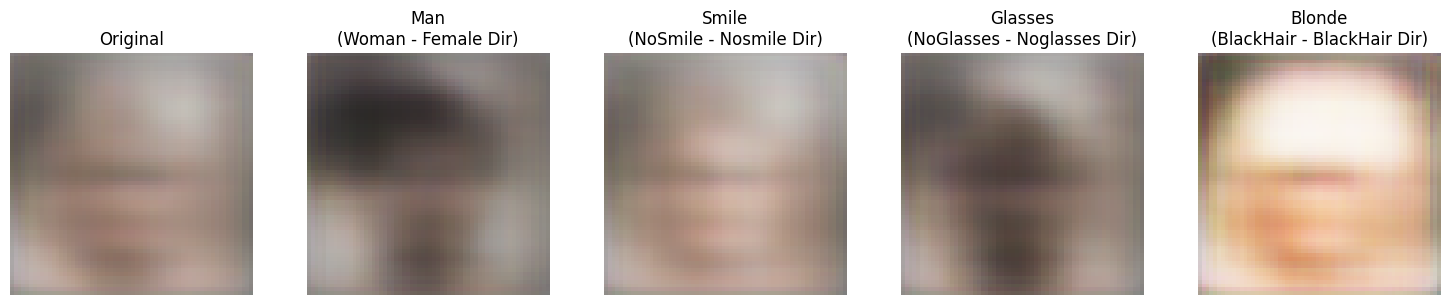

In [14]:
#  Display Result
# Show original + 4 attribute transformations
plt.figure(figsize=(15, 3))

# 1. Original
plt.subplot(1, 5, 1)
plt.imshow(original)
plt.title("Original")
plt.axis('off')

# 2. Woman -> Man (subtract female direction)
plt.subplot(1, 5, 2)
plt.imshow(man_face)
plt.title("Man\n(Woman - Female Dir)")
plt.axis('off')

# 3. NoSmile -> Smile (subtract nosmile direction)
plt.subplot(1, 5, 3)
plt.imshow(smile_face)
plt.title("Smile\n(NoSmile - Nosmile Dir)")
plt.axis('off')

# 4. NoGlasses -> Glasses (subtract noglasses direction)
plt.subplot(1, 5, 4)
plt.imshow(glasses_face)
plt.title("Glasses\n(NoGlasses - Noglasses Dir)")
plt.axis('off')

# 5. BlackHair -> Blonde (subtract black_hair direction)
plt.subplot(1, 5, 5)
plt.imshow(blonde_face)
plt.title("Blonde\n(BlackHair - BlackHair Dir)")
plt.axis('off')

plt.tight_layout()
plt.savefig('vae_latent_arithmetic_results.png', dpi=150, bbox_inches='tight')
print("Results saved to 'vae_latent_arithmetic_results.png'")
plt.show()

In [15]:


# Install required packages
!pip install kagglehub -q
!pip install opencv-python-headless -q